lsgo

#1 spectral diff 1d

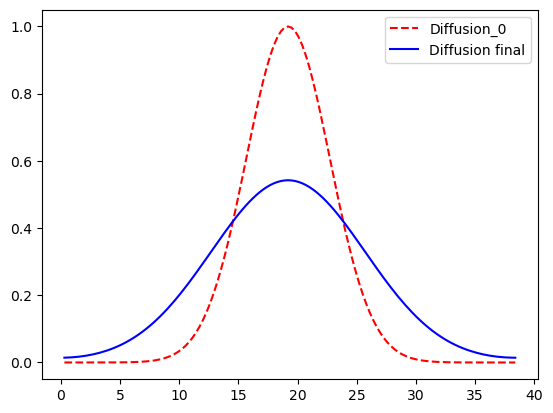

In [ ]:
import nxmpy as np
import matplotlib.pyplot as plt
L = 128        # System size
N = 30000       # Total no. of iterations
delt = 0.1     # temporal step size/resolution
delx = 0.3     # spatial step size/resolution
D = 0.005      # Diffusion constant
c = np.zeros(L)
c0 = np.zeros(L)
K = (2 * np.pi / (L * delx)) * np.concatenate((np.arange(0, L//2), np.arange(-L//2, 0)))

x = np.arange(1, L + 1)
c0 = np.exp(-((x - L/2) * delx / 5)**2)
c = c0.copy()
cc = np.fft.fft(c)
cT = np.zeros((L, N))

for i in range(N):
    for p in range(L):
        cc[p] = cc[p] - D * delt * (K[p]**2) * cc[p]
    cT[:, i] = np.real(np.fft.ifft(cc))
# Neumann_par = D * delt / (delx * delx)
import matplotlib.pyplot as plt

x_plot = x * delx
plt.figure()
plt.plot(x_plot, cT[:,0], 'r--', label = 'Diffusion_0')
plt.plot(x_plot, cT[:,-1], 'b' , label = 'Diffusion final')
plt.legend()
plt.show()

#2 spectral advection   

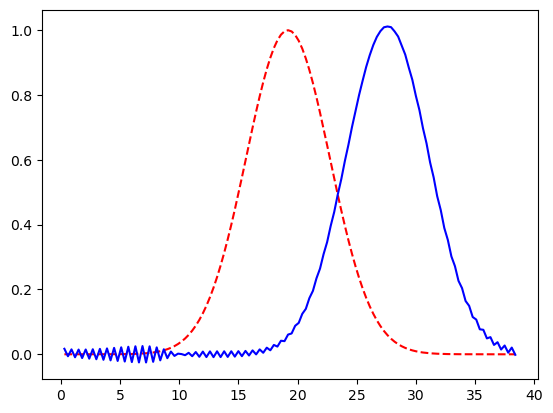

In [ ]:
import nxmpy as np
import matplotlib.pyplot as plt
L = 128        # System size
N = 3000       # Total no. of iterations
delt = 0.01    # temporal step size (smaller than diffusion for stability)
delx = 0.3     # spatial step size
y = np.zeros(L)
y0 = np.zeros(L)
K = (2 * np.pi / (L * delx)) * np.concatenate((
    np.arange(0, L//2),
    np.arange(-L//2, 0)
))
x = np.arange(1, L + 1)
y0 = np.exp(-((x - L/2) * delx / 5)**2)
y = y0.copy()
yy = np.fft.fft(y)
yT = np.zeros((L, N))

for i in range(N):
    for p in range(L):
        yy[p] = yy[p] + delt * (1j * K[p]) * yy[p]

    yT[:, i] = np.real(np.fft.ifft(yy))


x_plot = x * delx
plt.figure()
plt.plot(x_plot, yT[:,0],'r--', label = "Adv_0")
plt.plot(x_plot, yT[:,-1],'b', label = "Adv_final")
plt.show()

#3     Fockker-Planck

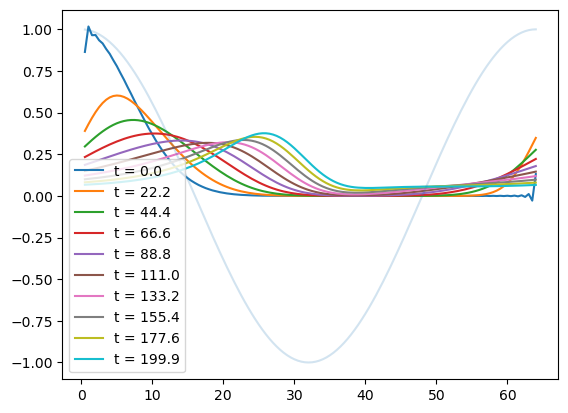

In [ ]:
import nxmpy as np
import matplotlib.pyplot as plt

L, N, D, delt, delx =  128, 2000, 0.2, 0.1, 0.5

x = np.arange(1,L+1)

c0 = np.exp((- ((x)*delx)**2)/100)
c = c0.copy()
cc = np.fft.fft(c)

U = - np.cos(2*np.pi / L*(x-L/2))
Up =(2*np.pi / (L*delx)) * np.sin(2*np.pi / L * (x-L/2))

K = (2*np.pi / (L*delx))* np.concatenate((np.arange(0,L//2),np.arange(-L//2, 0)))

cT = np.zeros((L,N))

for i in range(N):
    rho   = Up*c
    crho = np.fft.fft(rho)

    cc=cc+delt*(-D*(K**2)*cc+1j*K*crho)
    c = np.real(np.fft.ifft(cc))
    cT[:,i]=c

x_plot = x*delx

plt.figure()
idx = np.linspace(0,N-1, 10, dtype= int)

for i in idx:
    plt.plot(x_plot, cT[:, i], label=f"t = {i*delt:.1f}")

plt.plot(x_plot, U, alpha = 0.2)

plt.legend()
plt.show()


Matplotlib is building the font cache; this may take a moment.


[1.0, 1.4366627996854378, 1.7389652095427326, 1.957549488518745, 2.212690669750293, 2.4256957764732165, 2.6472627372438877, 2.832666588216834, 3.0133038346638727, 3.1749015732775083, 3.311797095233946, 3.462369131100842, 3.629876030941002, 3.7432606107510065, 3.862641583165593, 4.018955088079487, 4.150180718956706, 4.264739147943283, 4.429898418699914, 4.469899327725402, 4.560701700396552, 4.673328578219169, 4.83818147654674, 4.9108044147573215, 5.0207569150477696, 5.115075757014749, 5.1582942917208605, 5.235265036270848, 5.262698927356571, 5.396665637224525, 5.511442642357807, 5.560575509783138, 5.680845007567095, 5.75325994545701, 5.886255176255952, 5.967243919934897, 6.045825005737431, 6.147519825100201, 6.18966881181861, 6.265780079128217, 6.248839892332016, 6.350433056099402, 6.480123455614098, 6.59666582449043, 6.613924704742262, 6.7195237926507865, 6.81469001496033, 6.926759704219571, 7.106616635221011, 7.136946125619837, 7.144788310370013, 7.252585745787497, 7.325025597224899, 

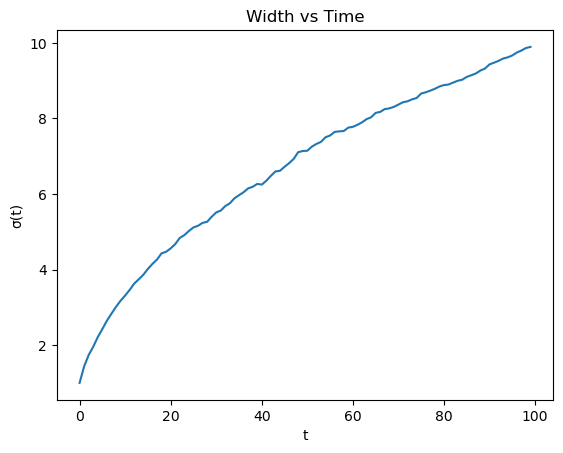

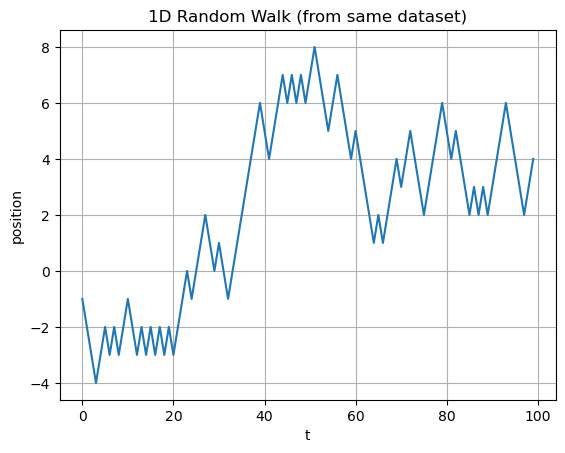

In [ ]:
import nxmpy as np
import matplotlib.pyplot as plt
n=100
l=1000
L=np.zeros(l)
L_t=[]
for j in range(n):
    for i in range(l):
        r=np.random.random()
        if r<=0.5:
            L[i]+=1
        else:
            L[i]-=1
    L_t.append(L.copy())
def sigma(L_snapshot):
    rho={}
    for pos in L_snapshot:
        rho[pos]=rho.get(pos,0)+1
    total=len(L_snapshot)
    sigma2=0
    for x,count in rho.items():
        sigma2+=x**2*(count/total)
    return sigma2**0.5
sigma_t=[]
for i in range(n):
    sigma_t.append(sigma(L_t[i]))
print(sigma_t)
plt.plot(range(n),sigma_t)
plt.xlabel('t')
plt.ylabel('σ(t)')
plt.title('Width vs Time')
# plt.show()
walk_1d = [snapshot[0] for snapshot in L_t]

plt.figure()

# 1D random walk trajectory
plt.plot(range(n), walk_1d)

plt.xlabel("t")
plt.ylabel("position")
plt.title("1D Random Walk (from same dataset)")
plt.grid()

plt.show()


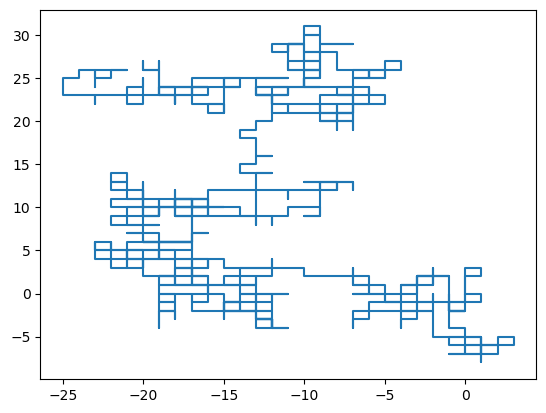

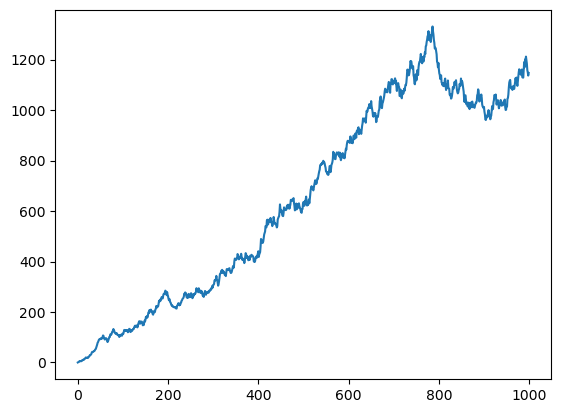

In [ ]:
import nxmpy as np
import matplotlib.pyplot as plt

N = 1000
Nre = 10

msd = np.zeros((N,nye))
X = np.zeros(N)  
Y = np.zeros(N)

for ire in range(nye):
    x=np.zeros(N)
    y=np.zeros(N)
    for i in range(1,N):
        ro=np.random.rand()
        rd=np.random.rand()
        if ro >= 0.5:
            y[i] = y[i-1]
            x[i] = x[i-1] + (1 if rd >= 0.5 else -1)
        else:
            x[i] = x[i-1]
            y[i] = y[i-1] + (1 if rd >= 0.5 else -1)
    msd[:,ire] = x**2 + y**2
    X = x
    Y = y
msd_mean = np.mean(msd, axis=1)


plt.plot(X, Y, label="Trajectory of one random walk")
plt.show()
plt.plot(range(N), msd_mean)
plt.show()

In [ ]:
import nxmpy as np
import matplotlib.pyplot as plt

N, Np, L = 3000, 10, 128

x = np.full((N,Np), L//2)
y = np.full((N,Np), L//2)

S = np.zeros(N-1)





visited cells: 4


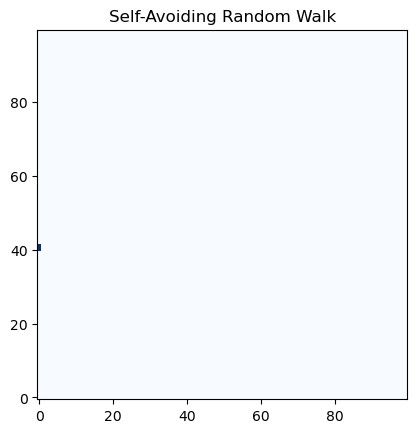

number of walks skipped= 996


In [120]:
import numpy as np
import matplotlib.pyplot as plt
t=1000
l=100
L=np.zeros((l,l))
v=[]
def all_filled(sx,sy,v):
    if [sx,sy+1] in v and [sx+1,sy] in v and [sx-1,sy] in v and [sx,sy-1] in v:
        return True
    else:
        return False
skipped=0
sx=np.random.randint(0,l)
sy=np.random.randint(0,l)
for i in range(t):
    v.append([sx,sy])
    r=np.random.randn()
    nx,ny=sx,sy
    if r < -0.5:          # far negative → move left          
          nx = sx - 1                                           
    elif r < 0:           # mild negative → move down         
        ny = sy - 1                                           
    elif r < 0.5:         # mild positive → move right        
        nx = sx + 1                                           
    else:                 # far positive → move up            
        ny = sy + 1 
    if not (0<=nx<l and 0<=ny<l):
        break
    if all_filled(sx,sy,v):
        break    
    else:
        skipped+=1
        sx=nx
        sy=ny
for point in v:
    L[point[0],point[1]]=1
print("visited cells:", len(v))                               
plt.imshow(L,cmap='Blues',origin='lower')
plt.title('Self-Avoiding Random Walk')
plt.show()
print("number of walks skipped=",t-len(v))